# Semantic Embeddings Exploration

**Purpose:** Compare theory-driven (handcrafted) lexical features vs. data-driven (Sentence-BERT) representations for HMM latent state discovery.

**Research Question:** Do handcrafted linguistic features and learned semantic representations discover the same latent group dynamics?

**Pipeline:**
1. Load transcript events (individual utterances)
2. Embed each utterance with Sentence-BERT (384-dim), then **mean-pool per 30s window**
3. PCA whitening to 50 components → **UMAP to 10 components** (cosine metric)
4. Save alongside lexical features for HMM comparison

**Why utterance-level pooling (not text concatenation):**
- `all-MiniLM-L6-v2` has a hard **256-token limit**; concatenated 30s multi-speaker windows routinely exceed this and are silently truncated
- Embedding each utterance separately eliminates truncation entirely (individual utterances are ~15–40 tokens)
- Mean-pooling over all speakers' utterances in a window preserves all contributions equally

**Why UMAP over PCA:**
- BERT embeddings are highly distributed — PCA requires >100 components to reach 80% variance
- UMAP (non-linear, cosine metric) preserves local cluster structure in far fewer dimensions
- Standard approach for sentence embedding visualisation and downstream ML

In [32]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
print(f"Repo root: {REPO_ROOT}")

Repo root: c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing


## 1. Install and Load Sentence-BERT

In [23]:
# Load sentence-transformers (already installed via terminal)
from sentence_transformers import SentenceTransformer
print("sentence-transformers loaded successfully")

sentence-transformers loaded successfully


In [24]:
# 256-token hard limit — utterance-level pooling (below) keeps us well under it
MODEL_NAME = "all-MiniLM-L6-v2"

print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)
print(f"Embedding dimension : {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length : {model.max_seq_length} tokens")

Loading all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5557.94it/s]


Embedding dimension : 384
Max sequence length : 256 tokens


## 2. Load Transcript Data and Reconstruct Window Texts

In [25]:
# Load the lexical features (for window metadata)
lex_path = REPO_ROOT / "analysis" / "results" / "lexical_window_30s.tsv"
lex_df = pd.read_csv(lex_path, sep="\t")
print(f"Loaded {len(lex_df)} windows from lexical features")
print(f"Groups: {lex_df['group_id'].nunique()}, Tasks: {lex_df['task_id'].unique().tolist()}")

Loaded 682 windows from lexical features
Groups: 10, Tasks: ['T1', 'T2', 'T3']


In [26]:
import re

# Load transcripts and reconstruct window texts
TRANSCRIPT_DIR = REPO_ROOT / "transcripts" / "final"
WINDOW_S = 30.0
PARTICIPANTS = ("P1", "P2", "P3", "P4")

_FNAME_RE = re.compile(r"transcript_(grp[_-]?\d+)_(T\d+)_", re.IGNORECASE)

def _normalize_group_id(raw: str) -> str:
    digits = re.sub(r"^grp[_-]?", "", raw.lower())
    return f"grp-{int(digits):02d}"

# Load all transcripts
all_events = []
for fpath in TRANSCRIPT_DIR.glob("*.tsv"):
    match = _FNAME_RE.search(fpath.name)
    if not match:
        continue
    group_id = _normalize_group_id(match.group(1))
    task_id = match.group(2).upper()
    
    df = pd.read_csv(fpath, sep="\t")
    df["group_id"] = group_id
    df["task_id"] = task_id
    all_events.append(df)

events_df = pd.concat(all_events, ignore_index=True)
print(f"Loaded {len(events_df)} transcript rows")

Loaded 7994 transcript rows


In [27]:
# Reconstruct window texts (same logic as lexical extraction)
window_texts = []

for (grp, task), grp_df in events_df.groupby(["group_id", "task_id"]):
    # Filter to SPK rows
    spk_df = grp_df[
        (grp_df["type"] == "SPK") & 
        (grp_df["speaker"].isin(PARTICIPANTS))
    ].copy()
    
    if spk_df.empty:
        continue
    
    # Assign window indices
    spk_df["window_index"] = (spk_df["onset"] / WINDOW_S).apply(
        lambda x: int(x) if pd.notna(x) and x >= 0 else -1
    )
    spk_df = spk_df[spk_df["window_index"] >= 0]
    
    max_window = int(spk_df["window_index"].max()) if not spk_df.empty else 0
    
    for win_idx in range(max_window + 1):
        win_df = spk_df[spk_df["window_index"] == win_idx]
        text = " ".join(win_df["text"].dropna().astype(str))
        
        window_texts.append({
            "group_id": grp,
            "task_id": task,
            "window_index": win_idx,
            "text": text.strip() if text.strip() else "",
            "word_count": len(text.split()) if text.strip() else 0,
        })

text_df = pd.DataFrame(window_texts)
print(f"Reconstructed {len(text_df)} window texts")
print(f"Empty windows: {(text_df['word_count'] == 0).sum()}")
print(f"Mean words per window: {text_df['word_count'].mean():.1f}")

Reconstructed 813 window texts
Empty windows: 216
Mean words per window: 41.8


In [8]:
# Preview some window texts
print("Sample window texts:")
for i, row in text_df[text_df["word_count"] > 20].head(3).iterrows():
    print(f"\n[{row['group_id']} {row['task_id']} win={row['window_index']}]")
    print(f"  {row['text'][:200]}...")

Sample window texts:

[grp-07 T1 win=6]
  If yes, why? Which candidate would you hire for this AI adoption and transformation specialist role? I can go. I think candidate C would be a right choice for this because this requires some experienc...

[grp-07 T1 win=7]
  And since this is a high-level position, not a technical position per se, I think candidate C would be better because they have experience both with sales and the technical domain. They also had some ...

[grp-07 T1 win=8]
  would be like an ideal must-have or like nice-to-have features for this particular position. I mean, I would agree to that. But actually, I was thinking of two candidates, A and C. mmh I think A also ...


## 3. Compute Sentence-BERT Embeddings (utterance-level pooling)

Each utterance is encoded independently, then mean-pooled per 30s window.  
This avoids the 256-token truncation that would occur when concatenating all speakers' text.

In [28]:
from collections import defaultdict

EMB_DIM = model.get_sentence_embedding_dimension()

# Filter to non-empty SPK utterances
spk_events = events_df[
    (events_df["type"] == "SPK") &
    (events_df["speaker"].isin(PARTICIPANTS)) &
    (events_df["text"].notna()) &
    (events_df["text"].str.strip() != "")
].copy()

spk_events["window_index"] = (spk_events["onset"] / WINDOW_S).apply(
    lambda x: int(x) if pd.notna(x) and x >= 0 else -1
)
spk_events = spk_events[spk_events["window_index"] >= 0].reset_index(drop=True)

# Token length sanity check — utterances should be well under the 256-token limit
word_counts = spk_events["text"].str.split().str.len()
approx_p99_tokens = word_counts.quantile(0.99) * 1.3
print(f"Utterance word counts — mean: {word_counts.mean():.1f}, max: {word_counts.max()}, p99: {word_counts.quantile(0.99):.0f}")
print(f"Approx p99 token count: ~{approx_p99_tokens:.0f}  (limit: {model.max_seq_length} tokens)")
if approx_p99_tokens > model.max_seq_length:
    print("  WARNING: some utterances may be truncated — inspect the longest ones")
else:
    print("  OK: utterance-level encoding is safely within the token limit")

# Encode all utterances in one batched pass
utterance_texts = spk_events["text"].tolist()
print(f"\nEncoding {len(utterance_texts)} utterances...")
utt_embeddings = model.encode(utterance_texts, show_progress_bar=True, batch_size=64)
print(f"Utterance embeddings shape: {utt_embeddings.shape}")

# Index utterance embeddings by (group_id, task_id, window_index)
win_to_utt_embs: dict = defaultdict(list)
for i, row in spk_events.iterrows():
    key = (row["group_id"], row["task_id"], int(row["window_index"]))
    win_to_utt_embs[key].append(utt_embeddings[i])

# Mean-pool per window, aligned to text_df row order
embeddings = np.zeros((len(text_df), EMB_DIM), dtype=np.float32)
valid_mask = np.zeros(len(text_df), dtype=bool)

for i, row in text_df.iterrows():
    key = (row["group_id"], row["task_id"], int(row["window_index"]))
    utt_embs = win_to_utt_embs.get(key)
    if utt_embs:
        embeddings[i] = np.stack(utt_embs).mean(axis=0)
        valid_mask[i] = True

text_df["bert_valid"] = valid_mask
print(f"\nFinal embeddings shape: {embeddings.shape}")
print(f"Windows with valid embeddings: {valid_mask.sum()} / {len(text_df)}")
print(f"Empty windows (zero vector, excluded from analysis): {(~valid_mask).sum()}")

Utterance word counts — mean: 10.5, max: 98, p99: 61
Approx p99 token count: ~79  (limit: 256 tokens)
  OK: utterance-level encoding is safely within the token limit

Encoding 3248 utterances...


Batches: 100%|██████████| 51/51 [00:09<00:00,  5.66it/s]


Utterance embeddings shape: (3248, 384)

Final embeddings shape: (813, 384)
Windows with valid embeddings: 597 / 813
Empty windows (zero vector, excluded from analysis): 216


In [10]:
# Empty windows get a zero vector — they are flagged bert_valid=False and excluded downstream
print(f"Windows with speech : {text_df['bert_valid'].sum()}")
print(f"Empty windows       : {(~text_df['bert_valid']).sum()}")

Empty windows (will have placeholder embedding): 216


## 4. Dimensionality Reduction: PCA whitening → UMAP

PCA alone is inefficient for sentence embeddings (variance is distributed across >100 components, as the plot below shows). The standard approach is:
1. **PCA to 50 components** (whitening) — removes noise and speeds up UMAP
2. **UMAP to 10 components** — non-linear, preserves local structure far better than PCA alone, appropriate for cosine-similarity spaces like sentence embeddings

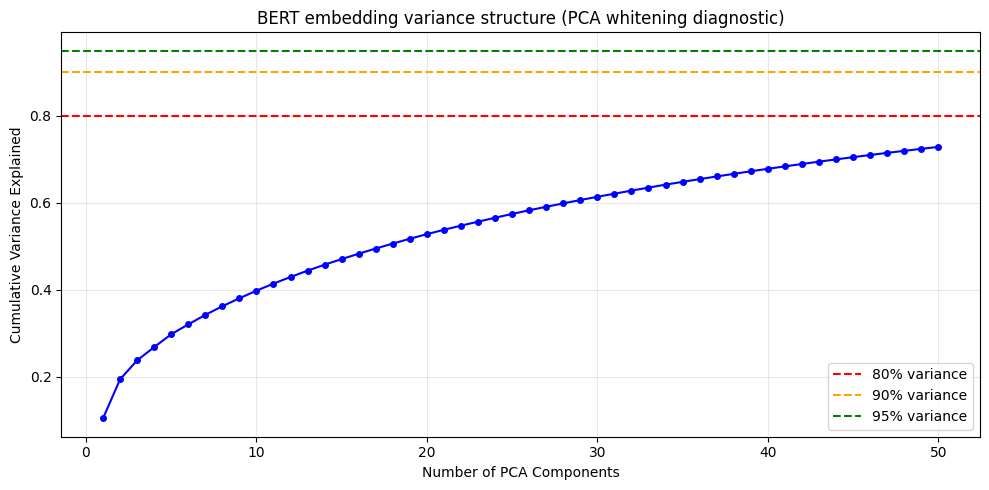

Variance explained by 50 components: 72.9%
Components for 80% variance: >50
Components for 90% variance: >50
Components for 95% variance: >50

Conclusion: BERT variance is highly distributed — UMAP (not PCA) is the right reduction tool.


In [33]:
N_WHITENING = 50

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# PCA whitening — diagnostic + preprocessing for UMAP
pca_full = PCA(n_components=N_WHITENING)
embeddings_white = pca_full.fit_transform(embeddings_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, N_WHITENING + 1), cumvar, "b-o", markersize=4)
ax.axhline(0.80, color="r",      linestyle="--", label="80% variance")
ax.axhline(0.90, color="orange", linestyle="--", label="90% variance")
ax.axhline(0.95, color="green",  linestyle="--", label="95% variance")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("BERT embedding variance structure (PCA whitening diagnostic)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# np.argmax returns 0 when condition is never met — guard against that bug
def _n_for_threshold(cumvar: np.ndarray, threshold: float) -> str:
    idx = np.argmax(cumvar >= threshold)
    return str(idx + 1) if cumvar[idx] >= threshold else f">{len(cumvar)}"

print(f"Variance explained by {N_WHITENING} components: {cumvar[-1]:.1%}")
print(f"Components for 80% variance: {_n_for_threshold(cumvar, 0.80)}")
print(f"Components for 90% variance: {_n_for_threshold(cumvar, 0.90)}")
print(f"Components for 95% variance: {_n_for_threshold(cumvar, 0.95)}")
print(f"\nConclusion: BERT variance is highly distributed — UMAP (not PCA) is the right reduction tool.")

In [34]:
from umap import UMAP

N_COMPONENTS = 10

# cosine metric is standard for sentence embeddings (matches how S-BERT was trained)
reducer = UMAP(
    n_components=N_COMPONENTS,
    n_neighbors=15,    # local neighborhood size — sensible for ~600 windows
    min_dist=0.1,      # allows tight clustering (better for HMM state separation)
    metric="cosine",
    random_state=42,   # reproducibility
)

print(f"Fitting UMAP: {N_WHITENING}d PCA → {N_COMPONENTS}d ...")
embeddings_umap = reducer.fit_transform(embeddings_white)

pca_cols = [f"bert_umap{i+1}" for i in range(N_COMPONENTS)]

print(f"UMAP output shape: {embeddings_umap.shape}")
print(f"Output columns   : {pca_cols}")

Fitting UMAP: 50d PCA → 10d ...
UMAP output shape: (813, 10)
Output columns   : ['bert_umap1', 'bert_umap2', 'bert_umap3', 'bert_umap4', 'bert_umap5', 'bert_umap6', 'bert_umap7', 'bert_umap8', 'bert_umap9', 'bert_umap10']


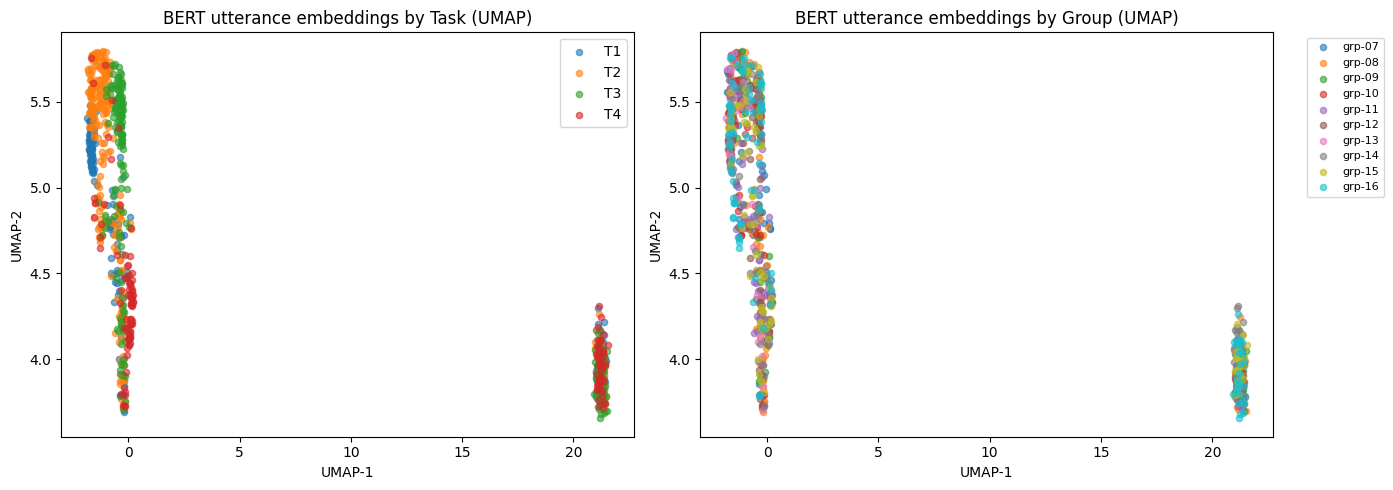

In [35]:
# Visualize first 2 UMAP components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for task in text_df["task_id"].unique():
    mask = text_df["task_id"] == task
    ax.scatter(embeddings_umap[mask, 0], embeddings_umap[mask, 1],
               label=task, alpha=0.6, s=20)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("BERT utterance embeddings by Task (UMAP)")
ax.legend()

ax = axes[1]
groups = text_df["group_id"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
for grp, color in zip(groups, colors):
    mask = text_df["group_id"] == grp
    ax.scatter(embeddings_umap[mask, 0], embeddings_umap[mask, 1],
               label=grp, alpha=0.6, s=20, color=color)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("BERT utterance embeddings by Group (UMAP)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 4b. Variance Decomposition: Task vs. Group

Before saving, check whether the BERT PCs discriminate **between tasks** (topic shifts T1→T4) or **between groups** (different interaction styles).  
This is critical for the thesis: if η²_task >> η²_group, BERT is primarily a topic encoder — useful as a baseline, but it does **not** capture group-specific dynamics the way turn-taking or participation features do.

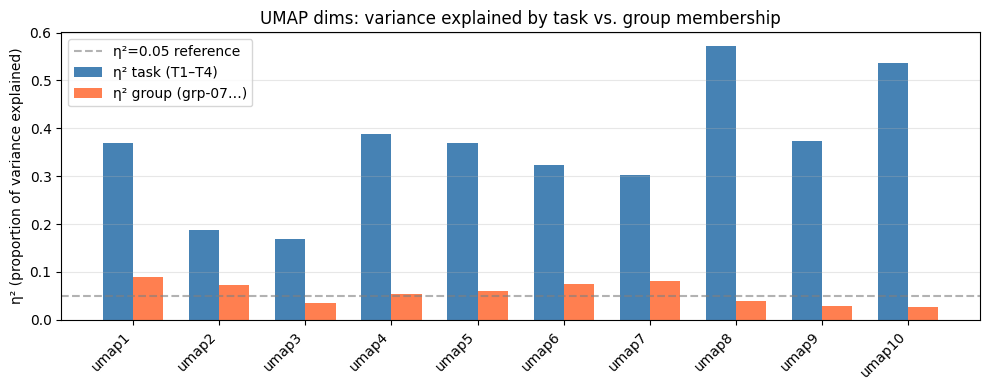

Mean η²_task  : 0.359
Mean η²_group : 0.056

If η²_task >> η²_group: BERT is mainly a task-topic encoder, not a group-dynamics encoder.
This is expected — and is the empirical basis for comparing it against your lexical features.


In [36]:
# η² decomposition: how much variance in each UMAP dim is explained by task vs. group?
# η²_task >> η²_group → embeddings mainly track topic shifts (T1→T4), not group differences
# η²_group > ~0.05    → embeddings also separate groups (useful for dynamics claims)

valid_umap = embeddings_umap[valid_mask]
valid_meta = text_df[valid_mask].reset_index(drop=True)

results = []
for pc_i in range(N_COMPONENTS):
    pc_vals = valid_umap[:, pc_i]
    grand_mean = pc_vals.mean()
    ss_total = ((pc_vals - grand_mean) ** 2).sum()

    task_masks = [(valid_meta["task_id"] == t).values for t in valid_meta["task_id"].unique()]
    ss_task = sum((pc_vals[m].mean() - grand_mean) ** 2 * m.sum() for m in task_masks)

    grp_masks = [(valid_meta["group_id"] == g).values for g in valid_meta["group_id"].unique()]
    ss_grp = sum((pc_vals[m].mean() - grand_mean) ** 2 * m.sum() for m in grp_masks)

    results.append({
        "Dim": f"umap{pc_i+1}",
        "η²_task": ss_task / ss_total if ss_total > 0 else 0.0,
        "η²_group": ss_grp / ss_total if ss_total > 0 else 0.0,
    })

var_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_COMPONENTS)
w = 0.35
ax.bar(x - w / 2, var_df["η²_task"],  w, label="η² task (T1–T4)",    color="steelblue")
ax.bar(x + w / 2, var_df["η²_group"], w, label="η² group (grp-07…)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(var_df["Dim"], rotation=45, ha="right")
ax.set_ylabel("η² (proportion of variance explained)")
ax.set_title("UMAP dims: variance explained by task vs. group membership")
ax.axhline(0.05, color="grey", linestyle="--", alpha=0.6, label="η²=0.05 reference")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Mean η²_task  : {var_df['η²_task'].mean():.3f}")
print(f"Mean η²_group : {var_df['η²_group'].mean():.3f}")
print()
print("If η²_task >> η²_group: BERT is mainly a task-topic encoder, not a group-dynamics encoder.")
print("This is expected — and is the empirical basis for comparing it against your lexical features.")

## 5. Save Embeddings for HMM Integration

In [37]:
# pca_cols now contains bert_umap1..N_COMPONENTS (defined in the UMAP cell)
embed_df = text_df[["group_id", "task_id", "window_index", "word_count"]].copy()

for i, col in enumerate(pca_cols):
    embed_df[col] = embeddings_umap[:, i]

embed_df["bert_valid"] = text_df["bert_valid"].values

print(embed_df.head())
print(f"\nShape: {embed_df.shape}")

  group_id task_id  window_index  word_count  bert_umap1  bert_umap2  \
0   grp-07      T1             0           0   21.355391    3.824878   
1   grp-07      T1             1           0   21.339928    3.887939   
2   grp-07      T1             2           0   21.340124    3.860594   
3   grp-07      T1             3           0   21.358559    3.789819   
4   grp-07      T1             4           0   21.389021    3.764402   

   bert_umap3  bert_umap4  bert_umap5  bert_umap6  bert_umap7  bert_umap8  \
0    5.780580    7.013358    4.191624    5.360804    4.170763    4.324002   
1    5.774868    7.057252    4.174632    5.354784    4.127373    4.388144   
2    5.791061    7.044844    4.148250    5.371404    4.114446    4.378030   
3    5.825041    6.966228    4.198652    5.382186    4.095842    4.278055   
4    5.814100    6.974681    4.224524    5.424256    4.112878    4.257153   

   bert_umap9  bert_umap10  bert_valid  
0    5.475197     4.583386       False  
1    5.537858     4.60

In [38]:
# Save to TSV
out_path = REPO_ROOT / "analysis" / "results" / "bert_embeddings_window_30s.tsv"
embed_df.to_csv(out_path, sep="\t", index=False)
print(f"Saved {len(embed_df)} rows to {out_path}")

Saved 813 rows to c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\bert_embeddings_window_30s.tsv


## 6. Compare with Lexical Features

In [39]:
# Merge BERT embeddings with lexical features
merged_df = lex_df.merge(
    embed_df[["group_id", "task_id", "window_index"] + pca_cols + ["bert_valid"]],
    on=["group_id", "task_id", "window_index"],
    how="inner"
)
print(f"Merged: {len(merged_df)} windows")

Merged: 682 windows


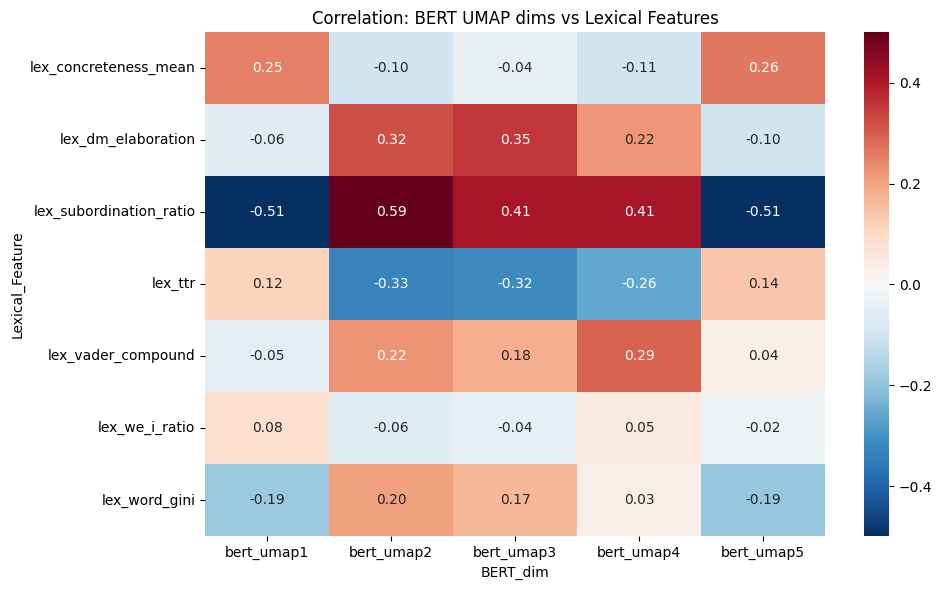


Interpretation:
- High |r|: UMAP dim captures similar information as lexical feature
- Low |r|: UMAP dim captures different/complementary information


In [40]:
# Correlate UMAP dims with key lexical features
key_lex_features = [
    "lex_ttr", "lex_vader_compound", "lex_dm_elaboration",
    "lex_we_i_ratio", "lex_word_gini", "lex_concreteness_mean",
    "lex_subordination_ratio"
]

valid_df = merged_df[merged_df["bert_valid"]].copy()

corr_data = []
for pc in pca_cols[:5]:
    for lex in key_lex_features:
        if lex in valid_df.columns:
            r = valid_df[[pc, lex]].dropna().corr().iloc[0, 1]
            corr_data.append({"BERT_dim": pc, "Lexical_Feature": lex, "r": r})

corr_df = pd.DataFrame(corr_data)
corr_pivot = corr_df.pivot(index="Lexical_Feature", columns="BERT_dim", values="r")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("Correlation: BERT UMAP dims vs Lexical Features")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High |r|: UMAP dim captures similar information as lexical feature")
print("- Low |r|: UMAP dim captures different/complementary information")

In [19]:
# Find strongest correlations
print("Strongest BERT-Lexical correlations:")
print("="*50)
strong = corr_df.reindex(corr_df['r'].abs().sort_values(ascending=False).index)
for _, row in strong.head(10).iterrows():
    print(f"  {row['BERT_PC']} ↔ {row['Lexical_Feature'].replace('lex_', '')}: r={row['r']:+.3f}")

Strongest BERT-Lexical correlations:
  bert_pc1 ↔ subordination_ratio: r=-0.598
  bert_pc2 ↔ subordination_ratio: r=-0.360
  bert_pc1 ↔ ttr: r=+0.342
  bert_pc2 ↔ concreteness_mean: r=+0.309
  bert_pc3 ↔ dm_elaboration: r=+0.286
  bert_pc3 ↔ subordination_ratio: r=+0.283
  bert_pc3 ↔ ttr: r=-0.279
  bert_pc5 ↔ subordination_ratio: r=-0.242
  bert_pc1 ↔ vader_compound: r=-0.227
  bert_pc5 ↔ dm_elaboration: r=-0.215


## 7. Summary

In [ ]:
print("="*60)
print("SEMANTIC EMBEDDINGS SUMMARY")
print("="*60)
print(f"Model              : {MODEL_NAME} (utterance-level pooling)")
print(f"Utterances encoded : {len(utterance_texts)}")
print(f"Original dim       : {model.get_sentence_embedding_dimension()}")
print(f"PCA whitening      : {N_WHITENING} components")
print(f"UMAP components    : {N_COMPONENTS}  (cosine metric, random_state=42)")
print(f"Windows embedded   : {len(embed_df)}")
print(f"Valid (non-empty)  : {embed_df['bert_valid'].sum()}")
print(f"Output columns     : {pca_cols}")
print(f"\nOutput: {out_path.name}")
print(f"\nReady for HMM comparison with lexical features!")
print("="*60)

SEMANTIC EMBEDDINGS SUMMARY
Model              : all-MiniLM-L6-v2 (utterance-level pooling)
Utterances encoded : 3248
Original dim       : 384
PCA whitening      : 50 components
UMAP components    : 10  (cosine metric, random_state=42)
Windows embedded   : 813
Valid (non-empty)  : 597
Output columns     : ['bert_umap1', 'bert_umap2', 'bert_umap3', 'bert_umap4', 'bert_umap5', 'bert_umap6', 'bert_umap7', 'bert_umap8', 'bert_umap9', 'bert_umap10']

Output: bert_embeddings_window_30s.tsv

Ready for HMM comparison with lexical features!


: 